In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

import optuna

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\Kanth\Downloads\synthetic_health_claims.csv")

In [4]:
df

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
0,67349080,XAI956194550,18874,2021-06-16,2021-05-01,2024-11-20,462337.48,28,Female,Houston,...,Rehab/Skilled Nursing,47,Inpatient,3440.06,824.59,0,16,939.08,True,False
1,85973291,XAI215993963,8762,2025-01-19,2025-01-17,2029-04-07,1883481.30,40,Other,Washington,...,Deceased,0,Outpatient,3618.40,851.43,0,6,170.40,False,True
2,62454860,XAI146653263,1920,2023-05-05,2023-03-24,2024-09-04,1500658.89,90,Female,Seattle,...,Deceased,0,Pharmacy,2442.41,616.23,0,2,549.38,True,False
3,58632240,XAI216596381,1316,2021-11-07,2021-11-02,2025-12-24,572237.61,49,Other,Fort Worth,...,Deceased,0,Pharmacy,587.78,459.33,0,2,396.49,False,True
4,96347311,XAI056900359,17039,2024-03-25,2024-02-18,2028-07-30,2088293.84,24,Female,New York,...,Deceased,0,Emergency Room,3047.55,847.40,0,15,865.87,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20095,96935977,XAI044413092,6472,2024-03-12,2024-02-25,2025-11-05,1182670.52,9,Male,Jacksonville,...,Rehab/Skilled Nursing,0,Emergency Room,3961.31,973.40,0,5,441.98,False,True
20096,11620007,XAI604243002,878,2024-10-19,2024-09-07,2029-09-20,1225019.60,60,Other,Los Angeles,...,Against Medical Advice,58,Inpatient,3383.95,998.72,0,0,602.85,True,False
20097,71153195,XAI115939441,4913,2022-04-05,2022-02-28,2026-03-23,1320858.11,15,Other,Chicago,...,Home,0,Outpatient,18.69,713.95,0,5,585.15,True,True
20098,58683401,XAI213569144,13498,2024-10-04,2024-09-26,2028-11-03,484552.40,41,Other,New York,...,Transfer to another facility,0,Emergency Room,3165.91,761.46,0,11,338.57,False,False


In [5]:
df.columns = df.columns.str.strip()

In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (20100, 30)


In [7]:
print("Duplicate rows:",df.duplicated().sum())
print("\nMissing values:\n",df.isnull().sum())
print("\nDataset information:\n")
df.info()
print("\nTarget distribution:\n",df["Is_Fraudulent"].value_counts())

Duplicate rows: 28

Missing values:
 Patient_ID                            0
Policy_Number                         0
Claim_ID                              0
Claim_Date                            0
Service_Date                          0
Policy_Expiration_Date                0
Claim_Amount                          0
Patient_Age                           0
Patient_Gender                        0
Patient_City                          0
Patient_State                         0
Hospital_ID                           0
Provider_Type                         0
Provider_Specialty                    0
Provider_City                         0
Provider_State                        0
Diagnosis_Code                        0
Procedure_Code                        0
Number_of_Procedures                  0
Admission_Type                        0
Discharge_Type                        0
Length_of_Stay_Days                   0
Service_Type                          0
Deductible_Amount                     0
CoP

In [8]:
df["Is_Fraudulent"] = (df["Is_Fraudulent"].astype(int))

In [10]:
date_cols = [
    "Claim_Date",
    "Service_Date",
    "Policy_Expiration_Date"
]

for col in date_cols:

    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

In [11]:
df["Claim_Delay_Days"] = (df["Claim_Date"] - df["Service_Date"]).dt.days

In [12]:
df["Days_To_Policy_Expiration"] = (df["Policy_Expiration_Date"] - df["Claim_Date"]).dt.days

In [13]:
df["Claim_Amount_Per_Procedure"] = (df["Claim_Amount"] / (df["Number_of_Procedures"] + 1))

In [14]:
df["Patient_Claim_Risk"] = (df["Number_of_Previous_Claims_Patient"] / (df["Patient_Age"] + 1))

In [15]:
df["Provider_Claim_Risk"] = (df["Number_of_Previous_Claims_Provider"] /(df["Number_of_Previous_Claims_Provider"] + 1))

In [16]:
df["Total_Previous_Claims"] = (df["Number_of_Previous_Claims_Patient"] +df["Number_of_Previous_Claims_Provider"])

In [17]:
df["Patient_Out_of_Pocket"] = (df["Deductible_Amount"] +df["CoPay_Amount"])

In [18]:
df["Claim_to_Patient_Cost_Ratio"] = (df["Claim_Amount"] / (df["Patient_Out_of_Pocket"] + 1))

In [19]:
df["Claim_Amount_Per_Stay_Day"] = (df["Claim_Amount"] /(df["Length_of_Stay_Days"] + 1))

In [20]:
df["Procedures_Per_Stay_Day"] = (df["Number_of_Procedures"] / (df["Length_of_Stay_Days"] + 1))

In [21]:
df["Claim_Year"] = (df["Claim_Date"].dt.year)

df["Claim_Month"] = (df["Claim_Date"].dt.month)

df["Claim_DayOfWeek"] = (df["Claim_Date"].dt.dayofweek)

df["Service_Year"] = (df["Service_Date"].dt.year)

df["Service_Month"] = (df["Service_Date"].dt.month)

In [22]:
df.drop(columns=[
        "Claim_Date",
        "Service_Date",
        "Policy_Expiration_Date"
    ],inplace=True)

In [23]:
df.drop(columns=[
        "Patient_ID",
        "Policy_Number",
        "Claim_ID",
        "Hospital_ID"
    ],inplace=True)

In [24]:
print("Dataset shape after feature engineering:",df.shape)
df.head()

Dataset shape after feature engineering: (20100, 38)


,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,Patient_State,Provider_Type,Provider_Specialty,Provider_City,Provider_State,Diagnosis_Code,...,Total_Previous_Claims,Patient_Out_of_Pocket,Claim_to_Patient_Cost_Ratio,Claim_Amount_Per_Stay_Day,Procedures_Per_Stay_Day,Claim_Year,Claim_Month,Claim_DayOfWeek,Service_Year,Service_Month
0,462337.48,28,Female,Houston,WI,Clinic,Cardiology,Los Angeles,WA,A09,...,16,4264.65,108.386173,9.632031e+03,0.041667,2021,6,2,2021,5
1,1883481.30,40,Other,Washington,CO,Laboratory,Cardiology,Dallas,AZ,J02.9,...,6,4469.83,421.282245,1.883481e+06,2.000000,2025,1,6,2025,1
2,1500658.89,90,Female,Seattle,FL,Hospital,Neurology,Phoenix,NC,I25.10,...,2,3058.64,490.469104,1.500659e+06,1.000000,2023,5,4,2023,3
3,572237.61,49,Other,Fort Worth,MD,Specialist Office,Pediatrics,Los Angeles,TX,I10,...,2,1047.11,545.970948,5.722376e+05,4.000000,2021,11,6,2021,11
4,2088293.84,24,Female,New York,FL,Specialist Office,Pediatrics,San Diego,PA,H25.9,...,15,3894.95,536.016592,2.088294e+06,5.000000,2024,3,0,2024,2


In [25]:
X = df.drop(columns=["Is_Fraudulent"])
y = df["Is_Fraudulent"]

In [26]:
print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (20100, 37)
y shape: (20100,)


In [27]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,test_size=0.2,random_state=21,stratify=y)

In [28]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=21,stratify=y_train_full)

In [29]:
num_cols = X.select_dtypes(exclude="object").columns

cat_cols = X.select_dtypes(include="object").columns

print("Numeric columns:")
print(list(num_cols))

print("\nCategorical columns:")
print(list(cat_cols))

Numeric columns:
['Claim_Amount', 'Patient_Age', 'Procedure_Code', 'Number_of_Procedures', 'Length_of_Stay_Days', 'Deductible_Amount', 'CoPay_Amount', 'Number_of_Previous_Claims_Patient', 'Number_of_Previous_Claims_Provider', 'Provider_Patient_Distance_Miles', 'Claim_Submitted_Late', 'Claim_Delay_Days', 'Days_To_Policy_Expiration', 'Claim_Amount_Per_Procedure', 'Patient_Claim_Risk', 'Provider_Claim_Risk', 'Total_Previous_Claims', 'Patient_Out_of_Pocket', 'Claim_to_Patient_Cost_Ratio', 'Claim_Amount_Per_Stay_Day', 'Procedures_Per_Stay_Day', 'Claim_Year', 'Claim_Month', 'Claim_DayOfWeek', 'Service_Year', 'Service_Month']

Categorical columns:
['Patient_Gender', 'Patient_City', 'Patient_State', 'Provider_Type', 'Provider_Specialty', 'Provider_City', 'Provider_State', 'Diagnosis_Code', 'Admission_Type', 'Discharge_Type', 'Service_Type']


In [30]:
preprocessor = ColumnTransformer(
    [
        ("Scaling", MinMaxScaler(), num_cols),
        ("Encoding", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

In [31]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): w for c, w in zip(classes, weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6660453557005281), 1: np.float64(2.0056127221702527)}


In [32]:
baseline_model = Sequential([
    Input(shape=(X_train_t.shape[1],)),
    Dense(112, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid"),
])

baseline_model.compile(optimizer="Adam", loss="binary_crossentropy", metrics=["accuracy"])

early = EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True)

baseline_model.fit(
    X_train_t, y_train,
    epochs=100,
    validation_data=(X_val_t, y_val),
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early],
    verbose=2,
)

Epoch 1/100
201/201 - 2s - 8ms/step - accuracy: 0.6884 - loss: 0.5965 - val_accuracy: 0.7139 - val_loss: 0.5637
Epoch 2/100
201/201 - 0s - 2ms/step - accuracy: 0.7575 - loss: 0.5260 - val_accuracy: 0.8109 - val_loss: 0.4452
Epoch 3/100
201/201 - 0s - 2ms/step - accuracy: 0.7894 - loss: 0.4816 - val_accuracy: 0.7901 - val_loss: 0.4563
Epoch 4/100
201/201 - 0s - 2ms/step - accuracy: 0.8117 - loss: 0.4450 - val_accuracy: 0.8097 - val_loss: 0.4381
Epoch 5/100
201/201 - 0s - 2ms/step - accuracy: 0.8333 - loss: 0.4085 - val_accuracy: 0.8302 - val_loss: 0.4059
Epoch 6/100
201/201 - 1s - 3ms/step - accuracy: 0.8518 - loss: 0.3744 - val_accuracy: 0.8113 - val_loss: 0.4252
Epoch 7/100
201/201 - 1s - 3ms/step - accuracy: 0.8644 - loss: 0.3390 - val_accuracy: 0.8025 - val_loss: 0.4406
Epoch 8/100
201/201 - 1s - 3ms/step - accuracy: 0.8797 - loss: 0.3031 - val_accuracy: 0.7833 - val_loss: 0.4973
Epoch 9/100
201/201 - 1s - 3ms/step - accuracy: 0.8966 - loss: 0.2692 - val_accuracy: 0.8147 - val_loss:

In [33]:
y_pred_baseline = np.where(baseline_model.predict(X_test_t) > 0.5, 1, 0)
print("Baseline test accuracy:", accuracy_score(y_test, y_pred_baseline))

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Baseline test accuracy: 0.8154228855721393


In [34]:
def objective(trial):
    lr_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 1, 4)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    activation = trial.suggest_categorical('activation', ['tanh', 'relu'])
    batch_size1 = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])

    model = Sequential()
    model.add(Input(shape=(X_train_t.shape[1],)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units{i}', 8, 128)
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.4)
        reg = trial.suggest_float(f'reg{i}', 1e-6, 1e-3, log=True)
        model.add(Dense(units, activation=activation, kernel_initializer="he_normal",
                         kernel_regularizer=l1_l2(l1=reg, l2=reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    opt_map = {
        'Adam': Adam(learning_rate=lr_rate),
        'RMSprop': RMSprop(learning_rate=lr_rate),
        'SGD': SGD(learning_rate=lr_rate)
    }
    model.compile(optimizer=opt_map[optimizer_name], loss='binary_crossentropy',
                  metrics=['accuracy'])

    es = EarlyStopping(monitor='val_accuracy', mode='max', patience=8, restore_best_weights=True)
    history = model.fit(
        X_train_t, y_train,
        epochs=60, batch_size=batch_size1,
        validation_data=(X_val_t, y_val),
        class_weight=class_weight_dict,
        callbacks=[es], verbose=0
    )
    return max(history.history['val_accuracy'])

In [35]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=21))
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-09-01 13:19:44,785] A new study created in memory with name: no-name-09860bf5-203d-46f3-a748-cf507d729c8a


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-01 13:20:01,810] Trial 0 finished with value: 0.7409825921058655 and parameters: {'learning_rate': 0.0001251554487151282, 'n_layers': 2, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 512, 'units0': 24, 'dropout0': 0.07124986462379934, 'reg0': 3.074600188548175e-05, 'units1': 112, 'dropout1': 0.30357753420484573, 'reg1': 0.0008155589837765903}. Best is trial 0 with value: 0.7409825921058655.
[I 2026-09-01 13:20:12,503] Trial 1 finished with value: 0.8423507213592529 and parameters: {'learning_rate': 0.00330069279804087, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 32, 'units0': 47, 'dropout0': 0.1840561335171904, 'reg0': 4.2964036649104274e-05, 'units1': 34, 'dropout1': 0.3199473307755906, 'reg1': 0.00015137471827762942}. Best is trial 1 with value: 0.8423507213592529.
[I 2026-09-01 13:20:25,768] Trial 2 finished with value: 0.8485696315765381 and parameters: {'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop'

In [36]:
best = study.best_params
n_layers = best['n_layers']

model = Sequential()
model.add(Input(shape=(X_train_t.shape[1],)))
for i in range(n_layers):
    model.add(Dense(best[f'units{i}'], activation=best['activation'], kernel_initializer="he_normal",
                     kernel_regularizer=l1_l2(l1=best[f'reg{i}'], l2=best[f'reg{i}'])))
    model.add(BatchNormalization())
    model.add(Dropout(best[f'dropout{i}']))
model.add(Dense(1, activation="sigmoid", kernel_initializer="glorot_uniform"))

opt_map = {
    'Adam': Adam(learning_rate=best['learning_rate']),
    'RMSprop': RMSprop(learning_rate=best['learning_rate']),
    'SGD': SGD(learning_rate=best['learning_rate'])
}
model.compile(optimizer=opt_map[best['optimizer']], loss="binary_crossentropy",
              metrics=["accuracy", tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")])

es = EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_t, y_train,
    epochs=250, batch_size=best['batch_size'],
    validation_data=(X_val_t, y_val),
    class_weight=class_weight_dict,
    callbacks=[es], verbose=2,
)

Epoch 1/250
101/101 - 2s - 20ms/step - accuracy: 0.6562 - auc: 0.7124 - loss: 0.9678 - recall: 0.6695 - val_accuracy: 0.7068 - val_auc: 0.7929 - val_loss: 0.8417 - val_recall: 0.7456
Epoch 2/250
101/101 - 0s - 4ms/step - accuracy: 0.7223 - auc: 0.7833 - loss: 0.8039 - recall: 0.7134 - val_accuracy: 0.7080 - val_auc: 0.8213 - val_loss: 0.7664 - val_recall: 0.7918
Epoch 3/250
101/101 - 0s - 4ms/step - accuracy: 0.7404 - auc: 0.8019 - loss: 0.7276 - recall: 0.7184 - val_accuracy: 0.8268 - val_auc: 0.8376 - val_loss: 0.5760 - val_recall: 0.5810
Epoch 4/250
101/101 - 0s - 4ms/step - accuracy: 0.7617 - auc: 0.8199 - loss: 0.6780 - recall: 0.7194 - val_accuracy: 0.8343 - val_auc: 0.8369 - val_loss: 0.5547 - val_recall: 0.4214
Epoch 5/250
101/101 - 0s - 4ms/step - accuracy: 0.7830 - auc: 0.8321 - loss: 0.6439 - recall: 0.7234 - val_accuracy: 0.8458 - val_auc: 0.8373 - val_loss: 0.5291 - val_recall: 0.5411
Epoch 6/250
101/101 - 0s - 5ms/step - accuracy: 0.7868 - auc: 0.8402 - loss: 0.6231 - rec

In [37]:
val_probs = model.predict(X_val_t).ravel()
thresholds = np.linspace(0.1, 0.9, 81)
accs = [accuracy_score(y_val, (val_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[int(np.argmax(accs))]
print(f"Best threshold from validation set: {best_threshold:.2f} (val acc = {max(accs):.4f})")

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   
Best threshold from validation set: 0.54 (val acc = 0.8635)


In [38]:
y_pred_train = np.where(model.predict(X_train_t) > best_threshold, 1, 0)
train_acc = accuracy_score(y_train, y_pred_train)

y_pred_val = np.where(model.predict(X_val_t) > best_threshold, 1, 0)
val_acc = accuracy_score(y_val, y_pred_val)

y_pred_test = np.where(model.predict(X_test_t) > best_threshold, 1, 0)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Train Accuracy      : 0.8645
Validation Accuracy : 0.8635
Test Accuracy       : 0.8565


In [40]:
print(classification_report(y_test,y_pred_test,target_names=[
            "Not Fraudulent",
            "Fraudulent"]))

                precision    recall  f1-score   support

Not Fraudulent       0.85      0.98      0.91      3018
    Fraudulent       0.89      0.48      0.63      1002

      accuracy                           0.86      4020
     macro avg       0.87      0.73      0.77      4020
  weighted avg       0.86      0.86      0.84      4020



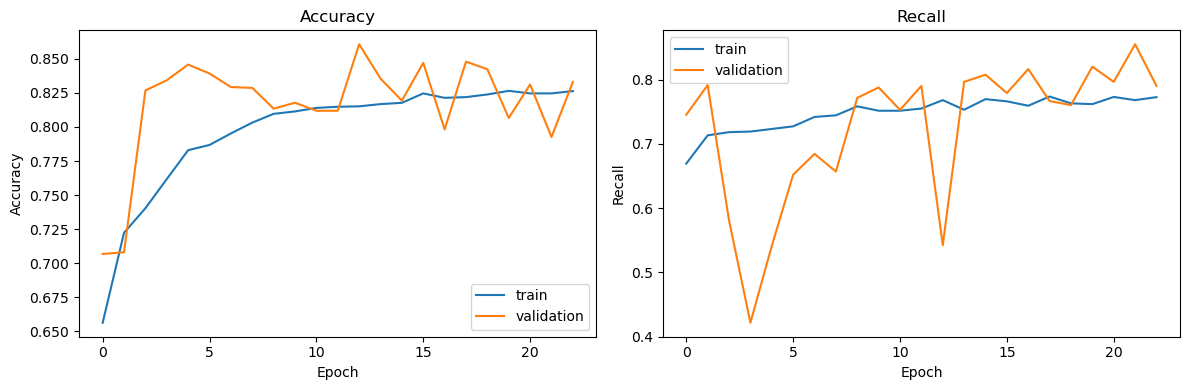

In [41]:
fig, axes = plt.subplots(1,2,figsize=(12, 4))
axes[0].plot(history.history["accuracy"],label="train")
axes[0].plot(history.history["val_accuracy"],label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["recall"],label="train")
axes[1].plot(history.history["val_recall"],label="validation")
axes[1].set_title("Recall")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [42]:
import pickle, json

with open("health_claims_preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

with open("health_claims_best_threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)

model.save("health_insurance_fraud_model.keras")
print("Model saved successfully")

Model saved successfully
